
# CAP4453 Assignment 2 — **Two‑Layer CNN (Minimal Template)**

This notebook is a **bare‑bones scaffold** for your Assignment 2 experiments.  
It includes **only** a two‑layer CNN example and **clearly marked** `# STUDENT TODO:`:
- **Data augmentation**
- **Image normalisation** (in the dataloader)
- **Batch Normalisation** (inside the model)
- **Optimizer & LR scheduler**
- **Training / validation / test loops**
- **Plots & analysis (e.g., misclassified examples)**

> **Important:** You must **design any deeper CNNs yourself** (e.g., 3‑layer or more). Do **not** expect ready‑made models here. You could design it in this notebook or in any other notebook/python files.



## Next steps
- **Architectural variations:** Modify the number of filters (`hidden_channels1`, `hidden_channels2`), change kernel sizes, or try different pooling strategies.
- **Make CNN deeper:** Add one or two extra convolutional layers. Does a deeper network improve accuracy?
- **Data augmentation:** Add transforms such as random cropping, horizontal flipping, colour jitter, and small rotations.
- **Data Normalisation:** Use `transforms.Normalize(mean, std)` in the **dataloader** after `ToTensor()`.
- **Batch Normalisation:** Insert `nn.BatchNorm2d(num_channels)` **after** `nn.Conv2d` and **before** `nn.ReLU()` in each block.
- **Comparison with Assignment 1:** Train your best 2‑layer and 3-layer CNNs and report test/val accuracy. Compare to Assignment 1’s linear and two‑layer fully connected baselines.
- **Analysis:** Identify misclassified examples and discuss patterns.


## 1. Setup (imports, device, seeds)

In [17]:
# Minimal imports
import os, random, time
from typing import Tuple

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility (optional)
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Device (CPU/GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda



## 2. Datasets & Transforms (augmentation + image normalisation)

- Switch dataset with `dataset_name`.
- **Add augmentation** inside the marked list(s).
- **Add image normalisation** via `transforms.Normalize(mean, std)` **after** `transforms.ToTensor()`.
- Keep augmentation **ON** for train only; for val/test typically only `ToTensor()` and **normalisation**.


In [18]:
# STUDENT TODO: choose dataset and flags
dataset_name = 'cifar10'  # 'cifar10' or 'mnist'  (STUDENT TODO)
AUGMENT      = True     # turn ON/OFF augmentation (STUDENT TODO)
USE_NORMALIZE= True      # turn ON/OFF image normalisation (STUDENT TODO)

# STUDENT TODO: adjust batch size and val split
batch_size = 512
val_ratio  = 0.1

# --- Build transforms (MINIMAL default: ToTensor only) ---
if dataset_name.lower() == 'cifar10':
    # TRAIN transforms (add augmentation in the list below)
    train_tfms_list = []
    if AUGMENT:
        # STUDENT TODO (AUGMENT): add items such as RandomCrop/HorizontalFlip/ColorJitter/Rotation, etc.
        # e.g., transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(p=0.5)
        train_tfms_list += [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomGrayscale(p=0.1),
        ]
    train_tfms_list += [transforms.ToTensor()]

    if USE_NORMALIZE:
        # STUDENT TODO (IMAGE NORMALISATION): typical CIFAR-10 stats
        train_tfms_list += [transforms.Normalize(mean=(0.4914,0.4822,0.4465), std=(0.2470,0.2435,0.2616))]

    test_tfms_list = [transforms.ToTensor()]
    if USE_NORMALIZE:
        # STUDENT TODO: same normalisation as train
         test_tfms_list += [transforms.Normalize(mean=(0.4914,0.4822,0.4465), std=(0.2470,0.2435,0.2616))]

    train_tfms = transforms.Compose(train_tfms_list)
    test_tfms  = transforms.Compose(test_tfms_list)

    train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tfms)
    test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tfms)
    num_classes = 10
    in_channels = 3

elif dataset_name.lower() == 'mnist':
    train_tfms_list = []
    if AUGMENT:
        # STUDENT TODO (AUGMENT for MNIST): small rotations/affine
        # e.g., transforms.RandomRotation(10)
        pass
    train_tfms_list += [transforms.ToTensor()]

    if USE_NORMALIZE:
        # STUDENT TODO (IMAGE NORMALISATION): typical MNIST stats
        # train_tfms_list += [transforms.Normalize(mean=(0.1307,), std=(0.3081,))]
        pass

    test_tfms_list = [transforms.ToTensor()]
    if USE_NORMALIZE:
        # STUDENT TODO: same normalisation as train
        # test_tfms_list += [transforms.Normalize(mean=(0.1307,), std=(0.3081,))]
        pass

    train_tfms = transforms.Compose(train_tfms_list)
    test_tfms  = transforms.Compose(test_tfms_list)

    train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=train_tfms)
    test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=test_tfms)
    num_classes = 10
    in_channels = 1
else:
    raise ValueError('Unknown dataset: choose cifar10 or mnist')

# --- Train/Val split ---
train_size = int((1.0 - val_ratio) * len(train_dataset))
val_size   = len(train_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_dataset)}')


Train: 45000 | Val: 5000 | Test: 10000



## 3. Two‑Layer CNN (only) — add BatchNorm where marked

> You must create **any deeper CNNs** in a **separate class** (your own file or below), using this as a starting point.


In [ ]:
class TwoLayerCNN(nn.Module):
    """A minimal two‑layer CNN.
    Block1: Conv -> (BatchNorm?) -> ReLU -> Pool
    Block2: Conv -> (BatchNorm?) -> ReLU -> Pool
    FC:     Linear to num_classes (lazy‑init after first forward)
    """
    def __init__(self, in_channels, num_classes, hidden_channels1=64, hidden_channels2=128, use_bn=True):
        super().__init__()
        self.use_bn = use_bn
        # --- Block 1 ---
        self.conv1 = nn.Conv2d(in_channels, hidden_channels1, kernel_size=3, padding=1, bias=not use_bn)
        # STUDENT TODO (BATCH NORM): if use_bn, insert nn.BatchNorm2d(hidden_channels1) before ReLU
        self.bn1   = nn.BatchNorm2d(hidden_channels1) if use_bn else nn.Identity()
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2)

        # --- Block 2 ---
        self.conv2 = nn.Conv2d(hidden_channels1, hidden_channels2, kernel_size=3, padding=1, bias=not use_bn)
        # STUDENT TODO (BATCH NORM): if use_bn, insert nn.BatchNorm2d(hidden_channels2) before ReLU
        self.bn2   = nn.BatchNorm2d(hidden_channels2) if use_bn else nn.Identity()
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2)

        # Classifier head will be created lazily (first forward) so you don't need to compute shapes by hand
        self.classifier = None
        self.num_classes = num_classes

    def forward(self, x):
      x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
      x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
      x = x.view(x.size(0), -1)

      if self.classifier is None:
          self.classifier = nn.Linear(x.size(1), self.num_classes).to(x.device)

      return self.classifier(x)

# STUDENT TODO: create your OWN deeper CNN class (e.g., ThreeLayerCNN) in another cell/file.
# Do NOT expect a prewritten deeper network here.


In [24]:
class ThreeLayerCNN(nn.Module):
    """A three-layer CNN.
    Block1: Conv -> (BN?) -> ReLU -> Pool
    Block2: Conv -> (BN?) -> ReLU -> Pool
    Block3: Conv -> (BN?) -> ReLU -> Pool
    FC:     Linear to num_classes (lazy-init)
    """
    def __init__(self, in_channels, num_classes,
                 hidden_channels1=64,
                 hidden_channels2=128,
                 hidden_channels3=256,
                 use_bn=True):
        super().__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(in_channels, hidden_channels1, kernel_size=3, padding=1, bias=not use_bn)
        self.bn1   = nn.BatchNorm2d(hidden_channels1) if use_bn else nn.Identity()
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2)

        # --- Block 2 ---
        self.conv2 = nn.Conv2d(hidden_channels1, hidden_channels2, kernel_size=3, padding=1, bias=not use_bn)
        self.bn2   = nn.BatchNorm2d(hidden_channels2) if use_bn else nn.Identity()
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2)

        # --- Block 3 (new) ---
        self.conv3 = nn.Conv2d(hidden_channels2, hidden_channels3, kernel_size=3, padding=1, bias=not use_bn)
        self.bn3   = nn.BatchNorm2d(hidden_channels3) if use_bn else nn.Identity()
        self.relu3 = nn.ReLU(inplace=True)

        self.pool3 = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = None
        self.num_classes = num_classes

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        if self.classifier is None:
            self.classifier = nn.Linear(x.size(1), self.num_classes).to(x.device)
        return self.classifier(x)

## 4. Optimizer & (optional) LR scheduler

In [ ]:
learning_rate = 2e-1
weight_decay  = 5e-4
momentum      = 0.9

model = TwoLayerCNN(in_channels, num_classes, use_bn=True,).to(device)  # STUDENT TODO: toggle use_bn, channels

# Example choices (uncomment ONE):
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)  # STUDENT TODO
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)                    # STUDENT TODO
# optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)  # STUDENT TODO

# STUDENT TODO (optional): uncomment LR scheduler for better accuracy
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
#scheduler = None

criterion = nn.CrossEntropyLoss()
print(model)


TwoLayerCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


In [31]:
learning_rate = 2e-1
weight_decay  = 5e-5
momentum      = 0.9

model = ThreeLayerCNN(in_channels, num_classes, use_bn=True,).to(device)  # STUDENT TODO: toggle use_bn, channels

# Example choices (uncomment ONE):
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)  # STUDENT TODO
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)                    # STUDENT TODO
# optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)  # STUDENT TODO

# STUDENT TODO (optional): uncomment LR scheduler for better accuracy
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
#scheduler = None

criterion = nn.CrossEntropyLoss()
print(model)


ThreeLayerCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU(inplace=True)
  (pool3): AdaptiveAvgPool2d(output_size=(2, 2))
)


## 5. Training / Validation — skeleton to complete

In [32]:
# STUDENT TODO: implement standard training & evaluation
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    # Pseudocode / hints
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
      x, y = x.to(device), y.to(device)
      optimizer.zero_grad()          # clear old gradients
      logits = model(x)              # forward pass
      loss = criterion(logits, y)    # compute loss
      loss.backward()                # backprop
      optimizer.step()               # update weights

      # Accumulate metrics
      total_loss += loss.item() * x.size(0)   # un-average the batch loss
      preds = logits.argmax(dim=1)
      correct += (preds == y).sum().item()
      total   += x.size(0)

    avg_loss = total_loss / total
    avg_acc  = 100.0 * correct / total
    return avg_loss, avg_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()   # BN uses running stats
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total   += x.size(0)

    return total_loss / total, 100.0 * correct / total


## 6. Run training (log metrics, make plots)

NVIDIA A100-SXM4-40GB
Epoch 01/50 | Train 1.6396/42.64% | Val 1.5741/43.72%
Epoch 02/50 | Train 1.3236/55.14% | Val 1.2795/55.26%
Epoch 03/50 | Train 1.1694/60.48% | Val 1.1739/60.00%
Epoch 04/50 | Train 1.0770/63.74% | Val 1.1486/59.48%
Epoch 05/50 | Train 1.0017/66.21% | Val 1.0550/64.28%
Epoch 06/50 | Train 0.9534/67.83% | Val 1.0020/65.98%
Epoch 07/50 | Train 0.8919/70.25% | Val 0.9527/67.78%
Epoch 08/50 | Train 0.8520/71.41% | Val 0.9342/67.94%
Epoch 09/50 | Train 0.8252/72.28% | Val 0.9889/65.56%
Epoch 10/50 | Train 0.7913/73.61% | Val 0.9474/66.86%
Epoch 11/50 | Train 0.7690/74.29% | Val 0.9132/68.68%
Epoch 12/50 | Train 0.7468/74.98% | Val 0.9191/67.02%
Epoch 13/50 | Train 0.7271/75.64% | Val 0.7852/73.32%
Epoch 14/50 | Train 0.7059/76.38% | Val 0.7523/74.52%
Epoch 15/50 | Train 0.6887/77.08% | Val 0.7878/73.18%
Epoch 16/50 | Train 0.6769/77.49% | Val 0.8015/72.54%
Epoch 17/50 | Train 0.6664/77.82% | Val 0.7920/72.42%
Epoch 18/50 | Train 0.6499/78.24% | Val 0.7166/75.50%
Epoch 

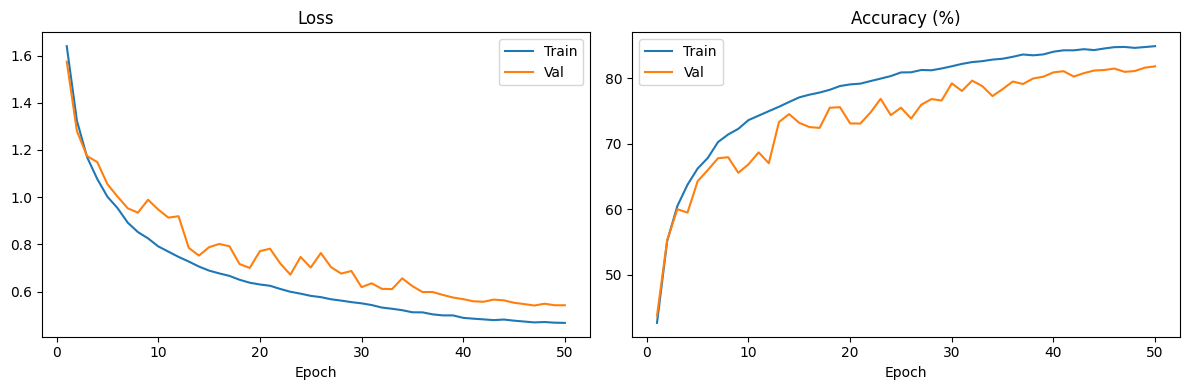

Final Test Loss: 0.4680 | Final Test Accuracy: 84.14%


In [33]:
print(torch.cuda.get_device_name(0))
num_epochs = 50
train_hist, val_hist = [], []
torch.backends.cudnn.benchmark = True
# --- Training loop ---
for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)

    train_hist.append((tr_loss, tr_acc))
    val_hist.append((va_loss, va_acc))

    if scheduler is not None:
        scheduler.step()

    print(f"Epoch {epoch:02d}/{num_epochs} | "
          f"Train {tr_loss:.4f}/{tr_acc:.2f}% | "
          f"Val {va_loss:.4f}/{va_acc:.2f}%")

# --- Plot train/val curves ---
epochs = range(1, num_epochs + 1)
tr_losses = [h[0] for h in train_hist]
va_losses = [h[0] for h in val_hist]
tr_accs   = [h[1] for h in train_hist]
va_accs   = [h[1] for h in val_hist]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, tr_losses, label='Train')
ax1.plot(epochs, va_losses, label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(epochs, tr_accs, label='Train')
ax2.plot(epochs, va_accs, label='Val')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.show()

# --- Evaluate test set after all epochs ---
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final Test Loss: {test_loss:.4f} | Final Test Accuracy: {test_acc:.2f}%")

## 7. Analysis — misclassified examples (optional)

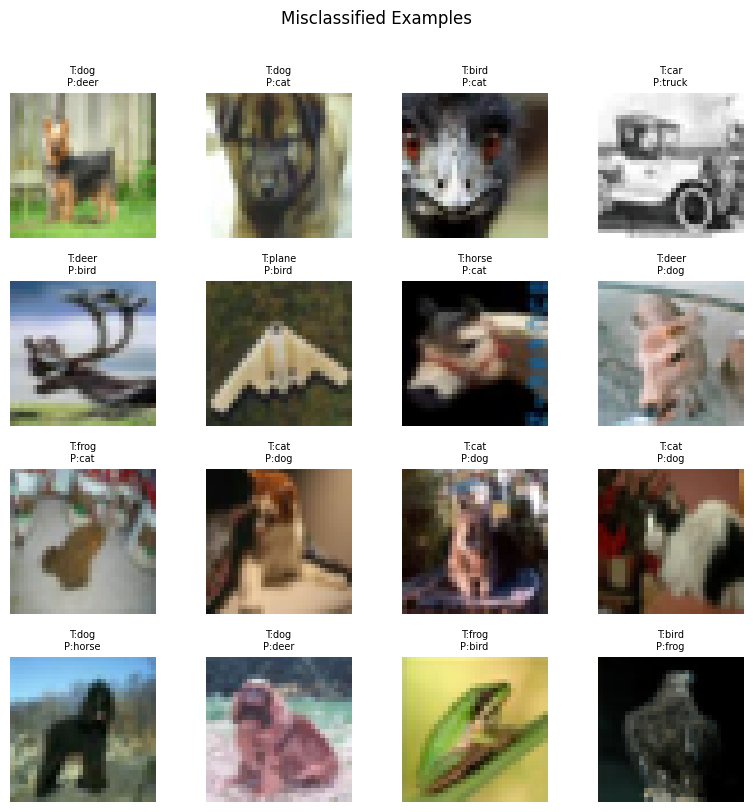

In [34]:
# STUDENT TODO: display a small grid of misclassified images
# Hints:
# - collect logits, compare argmax with true labels, store a few errors
# - if you used Normalize, consider an inverse normalisation for display
# - use matplotlib to show images with predicted/true labels
model.eval()
mistakes = []  # list of (image, true_label, pred_label)

cifar10_classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(dim=1)
        wrong = (preds != y).nonzero(as_tuple=True)[0]  # indices of wrong predictions
        for idx in wrong:
            if len(mistakes) >= 16:   # only need a small grid
                break
            mistakes.append((x[idx].cpu(), y[idx].item(), preds[idx].item()))

# --- Inverse normalise if USE_NORMALIZE was True ---
def unnormalize(img, mean=(0.4914,0.4822,0.4465), std=(0.2470,0.2435,0.2616)):
    # img: C×H×W tensor
    mean = torch.tensor(mean).view(3,1,1)
    std  = torch.tensor(std).view(3,1,1)
    return img * std + mean   # reverse: x = z*std + mean

# --- Plot grid ---
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, (img, true, pred) in zip(axes.flat, mistakes):
    if USE_NORMALIZE:
        img = unnormalize(img)
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()  # C×H×W → H×W×C
    ax.imshow(img if in_channels == 3 else img.squeeze(), cmap=None if in_channels==3 else 'gray')
    ax.set_title(f'T:{cifar10_classes[true]}\nP:{cifar10_classes[pred]}', fontsize=7)
    ax.axis('off')

plt.suptitle('Misclassified Examples', y=1.01)
plt.tight_layout()
plt.show()
